##Introduction à la Classification
La classification est l’une des tâches fondamentales en apprentissage supervisé. Elle consiste à prédire une catégorie à partir d’observations.

Contrairement à la régression, où l’on prédit une valeur numérique continue, la classification prédit des labels discrets (ex. : spam / non-spam, malade / non-malade, client qui achète / n'achète pas).


L’algorithme le plus utilisé pour la classification binaire est **la régression logistique**. Malgré son nom, il s’agit d’un classificateur, pas d’un modèle de régression linéaire.

Elle est appréciée car :



*  simple à implémenter






*   interprétable,
*   Éefficace sur des données linéairement séparables

La classification est une technique d'Apprentissage Supervisé (Supervised Learning).

L'entrée (Input) : Des données avec des caractéristiques (ex: âge, salaire, pixels d'une image).

La sortie (Output) : Une étiquette ou une classe (discrète).

**Les Types de Classification** :

Il existe deux grandes familles que nous rencontrons souvent :



1.   Classification Binaire (Celle de notre atelier)


*   Il n'y a que deux issues possibles.
*   Souvent notées 0  et 1 .


2.   Classification Multi-classes :


*   Il y a plus de deux catégories.
*   ÉExemple : reconnaître si un fruit est pomme, banane ou orange.



## Qu’est-ce que la Régression Logistique
La régression logistique est un algorithme d’apprentissage supervisé utilisé pour prédire une probabilité, généralement dans un problème de classification binaire (0 ou 1).

Elle transforme une combinaison linéaire des entrées en une probabilité grâce à la fonction sigmoïde :
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Le résultat est une valeur entre 0 et 1.

C'est ce qu'on appelle la Règle de Décision (Decision Rule).

$$\hat{y} = \begin{cases} 1 & \text{si } \sigma(z) \geq 0.5 \\ 0 & \text{sinon} \end{cases}$$

Pourquoi ne pas utiliser la régression linéaire ?

La régression linéaire n’est pas adaptée à la classification pour plusieurs raisons :

→ Elle peut prédire n’importe quelle valeur (−∞ à +∞)

→ impossible de l’interpréter comme une probabilité.
 exemples :

*   σ(z) = 0.51 → le modèle est peu sûr que c’est la classe 1
*   σ(z) = 0.99 → le modèle est très sûr


*   σ(z) = 0.01 → il est presque certain que c’est la classe 0


La régression logistique utilise une fonction appelée log-loss pour apprendre les meilleurs paramètres du modèle.



Régression LOGISTIQUE (Prédire une classe 0 ou 1) :


1.   On utilise la Log Loss (aussi appelée Binary Cross-Entropy).
2.   On mesure une probabilité

 La Formule Mathématique (Log Loss).

 Soit :$y$ : La vraie valeur (soit 0, soit 1).

 $\hat{y}$ (ou $p$) : La probabilité prédite par votre modèle (entre 0 et 1).

 $\log$ : Le logarithme népérien.$$Cost(y, \hat{y}) = - [ y \cdot \log(\hat{y}) + (1 - y) \cdot \log(1 - \hat{y}) ]$$
y = 1, ŷ = 0.01 → perte très élevée

y = 1, ŷ = 0.9 → perte faible





👉 Comment apprend la régression logistique ?

On cherche les paramètres w et b

On minimise la Log Loss

On utilise la descente de gradient

### le pipeline Machine Learning


Données

Features (X) / Target (y)

Entraînement

Prédiction

Décision (0 / 1)

Évaluation

Objectif de l’atelier

Cet atelier a pour objectif d’utiliser la régression logistique afin de prédire si un étudiant est admis ou refusé à l’université.

 En se basant sur les notes obtenues à l’examen et à l’entretien, le modèle calculera la probabilité d’admission et appliquera une règle de décision pour classer chaque étudiant en admis (1) ou non admis (0).

  Cet exemple permettra de comprendre concrètement le principe de la classification binaire et l’interprétation des résultats.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Charger le dataset





In [29]:
df = pd.read_csv('university_admission_dataset.csv')

In [30]:
df

,exam_score,interview_score,admitted
0,78,53,1
1,91,62,1
2,68,99,1
3,54,96,1
4,82,79,1
...,...,...,...
95,53,82,0
96,70,68,1
97,87,75,1
98,54,52,0


In [4]:
df['exam_score']

,exam_score
0,78
1,91
2,68
3,54
4,82
...,...
95,53
96,70
97,87
98,54


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   exam_score       100 non-null    int64
 1   interview_score  100 non-null    int64
 2   admitted         100 non-null    int64
dtypes: int64(3)
memory usage: 2.5 KB


In [6]:
df.describe()

,exam_score,interview_score,admitted
count,100.000000,100.000000,100.000000
mean,69.580000,69.070000,0.600000
std,18.031499,16.811645,0.492366
min,41.000000,40.000000,0.000000
25%,54.000000,54.000000,0.000000
50%,68.000000,70.000000,1.000000
75%,86.000000,81.250000,1.000000
max,99.000000,99.000000,1.000000


### Description du dataset





| Colonne           | Description                    |
| ----------------- | ------------------------------ |
| `exam_score`      | Note à l’examen (40–100)       |
| `interview_score` | Note à l’entretien (40–100)    |
| `admitted`        | 0 = refusé, 1 = admis (target) |


In [7]:
df.isnull().sum()

,0
exam_score,0
interview_score,0
admitted,0


In [8]:
X = df[["exam_score", "interview_score"]]
y = df["admitted"]

In [9]:
X

,exam_score,interview_score
0,78,53
1,91,62
2,68,99
3,54,96
4,82,79
...,...,...
95,53,82
96,70,68
97,87,75
98,54,52


In [10]:
y

,admitted
0,1
1,1
2,1
3,1
4,1
...,...
95,0
96,1
97,1
98,0


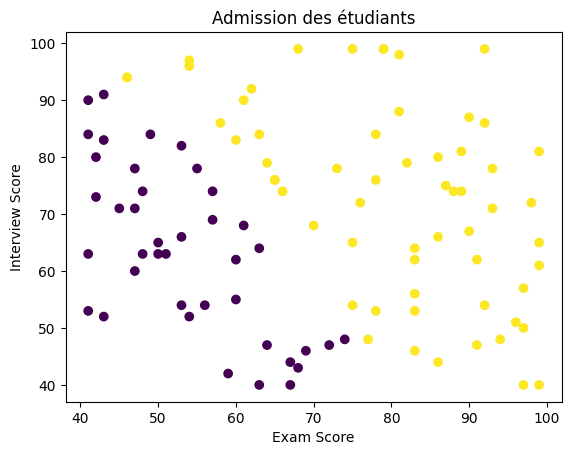

In [11]:
import matplotlib.pyplot as plt

plt.scatter(df["exam_score"], df["interview_score"], c=df["admitted"])
plt.xlabel("Exam Score")
plt.ylabel("Interview Score")
plt.title("Admission des étudiants")
plt.show()


**Graphique 2D : La Séparation Visuelle** **:**


*   Les deux groupes (Admis et Refusés) sont clairement regroupés dans des zones opposées.

*   On distingue un "couloir" vide entre les points jaunes et violets.



*   Cela prouve qu'il est possible de tracer une frontière de décision linéaire entre eux.











## Graphiques 1D :


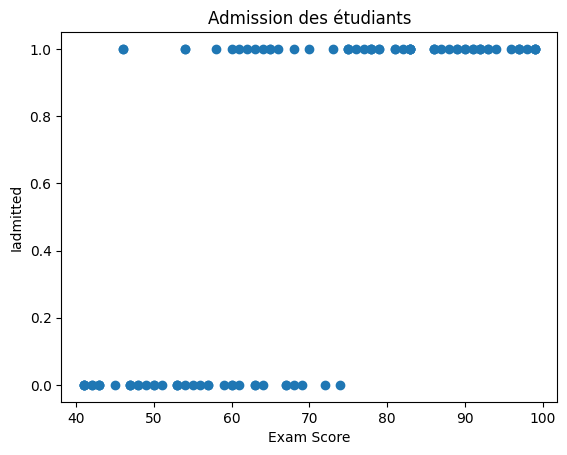

In [12]:
plt.scatter(df["exam_score"], df["admitted"])
plt.xlabel("Exam Score")
plt.ylabel("Iadmitted")
plt.title("Admission des étudiants")
plt.show()


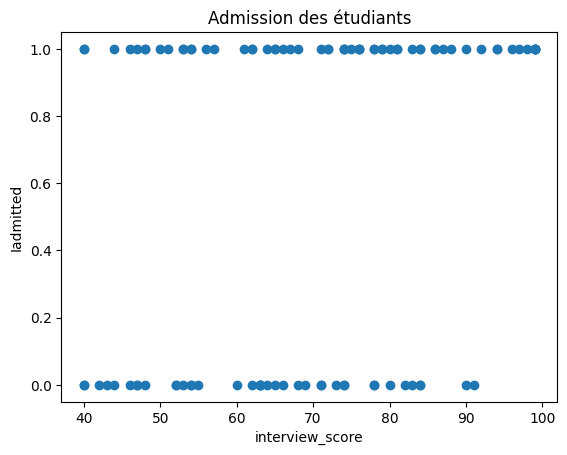

In [13]:
plt.scatter(df["interview_score"], df["admitted"])
plt.xlabel("interview_score")
plt.ylabel("Iadmitted")
plt.title("Admission des étudiants")
plt.show()


Graphiques 1D : Le problème de la "Mauvaise Forme"



*   Les données forment un escalier brutal : on est soit à 0, soit à 1.

*   Il est impossible de tracer une droite linéaire, car les données sont séparées en deux classes distinctes. Dans ce cas, une régression linéaire n’est pas appropriée.Élément de liste


  


*   La Régression Linéaire peut prédire des valeurs infinies (de $-\infty$ à $+\infty$).
*   C'est impossible : une probabilité doit obligatoirement rester bornée entre 0 et 1.








## Entrainement de Modele

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

### 1. Définir X (Features) et y (Target)

In [15]:
X = df[['exam_score', 'interview_score']]
y = df['admitted']

###  2. Séparer les données (80% pour apprendre, 20% pour tester)
### C'est important pour vérifier si le modèle marche sur des étudiants qu'il n'a jamais vus.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 3. Mise à l'échelle (StandardScaler)
### La régression logistique fonctionne mieux si les notes sont "centrées" autour de 0.

In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 4. Création et Entraînement du modèle

In [18]:
model = LogisticRegression()

In [19]:
model.fit(X_train_scaled, y_train)

LogisticRegression()

### Cas 1️⃣ : prédire sur le jeu d’entraînement (juste pour vérifier)

In [34]:
y_pred_train=model.predict(X_train_scaled)

In [35]:
y_pred_train

array([1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0,
       1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1,
       1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1])

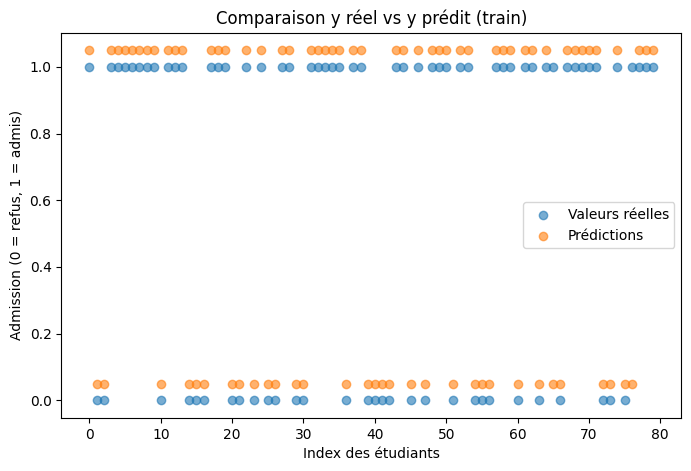

In [39]:
plt.figure(figsize=(8, 5))

plt.scatter(range(len(y_train)), y_train,
            label="Valeurs réelles", alpha=0.6)

plt.scatter(range(len(y_pred_train)),
            y_pred_train + 0.05,   # petit décalage vertical
            label="Prédictions",
            alpha=0.6)

plt.legend()
plt.xlabel("Index des étudiants")
plt.ylabel("Admission (0 = refus, 1 = admis)")
plt.title("Comparaison y réel vs y prédit (train)")
plt.show()


### Cas 2️⃣ : prédire sur le jeu de test

In [40]:
y_pred_test=model.predict(X_test_scaled)

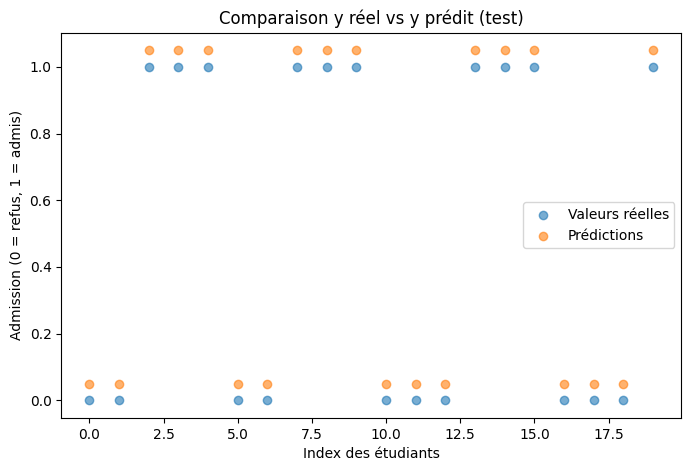

In [42]:
plt.figure(figsize=(8, 5))

plt.scatter(range(len(y_test)), y_test,
            label="Valeurs réelles", alpha=0.6)

plt.scatter(range(len(y_pred_test)),
            y_pred_test + 0.05,  # petit décalage vertical
            label="Prédictions", alpha=0.6)

plt.legend()
plt.xlabel("Index des étudiants")
plt.ylabel("Admission (0 = refus, 1 = admis)")
plt.title("Comparaison y réel vs y prédit (test)")
plt.show()


Bien que la visualisation suggère une forte concordance entre les prédictions et les valeurs réelles sur le jeu de test, cette observation doit être confirmée par des métriques quantitatives afin d’éviter toute conclusion hâtive.



> Avant l’évaluation du modèle, nous avons validé son comportement sur des exemples synthétiques afin de vérifier la cohérence des prédictions pour des étudiants jamais vus.



In [43]:
import numpy as np

new_student = np.array([[75, 80]])

In [44]:
new_student_scaled = scaler.transform(new_student)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [64]:
prediction = model.predict(new_student_scaled)
prediction


array([1])

In [65]:
proba = model.predict_proba(new_student_scaled)
proba


array([[0.04156619, 0.95843381]])

In [78]:
tests = np.array([
    [90, 80],  # très bon
    [40, 45],  # très faible
    [70, 60],  # moyen
    [85, 50]   # exam fort, interview faible
])

In [79]:
tests_scaled = scaler.transform(tests)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [80]:
pred=model.predict(tests_scaled)
pred

array([1, 0, 1, 1])

### Évaluer un modèle

Pourquoi on évalue un modèle ?

Parce qu’un modèle qui apprend bien n’est pas forcément un modèle qui généralise bien.

L’évaluation sert à :


*   mesurer la qualité réelle du modèle

*   comprendre où et comment il se trompe
*   décider s’il est utilisable en pratique










1️⃣ Accuracy

🔹 Quand l’utiliser ?


*   Classes équilibrées
*   Coût des erreurs similaire

🔹 Ce que ça mesure


*   Proportion totale de prédictions correctes.



🔹 Pourquoi c’est important


*   Très simple

*   Donne une vue globale









2️⃣ Matrice de confusion (INDISPENSABLE)

🔹 Quand l’utiliser ?

👉 Toujours. Sans exception.

🔹 Ce que ça montre



*   Vrais positifs

*   Faux positifs
*   Faux négatifs


*   Vrais négatifs





🔹 Pourquoi c’est crucial

Montre le type d’erreurs

Permet de juger si le modèle est acceptable métier

📌 Exemple :

Faux négatif = refuser un bon étudiant → grave

Faux positif = accepter un mauvais étudiant → grave aussi, mais différemment

3️⃣ Precision

🔹 Quand l’utiliser ?

Quand les faux positifs sont coûteux

🔹 Ce que ça mesure

Parmi ceux prédits positifs, combien sont vraiment positifs.

🔹 Pourquoi c’est important

Fiabilité des prédictions positives

📌 Exemple :

Admission universitaire → ne pas admettre des étudiants non qualifiés.

In [81]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns # Pour un affichage plus joli
import matplotlib.pyplot as plt

In [82]:
y_pred = model.predict(X_test_scaled)

In [83]:
cm = confusion_matrix(y_test, y_pred)

In [85]:
cm

array([[10,  0],
       [ 0, 10]])

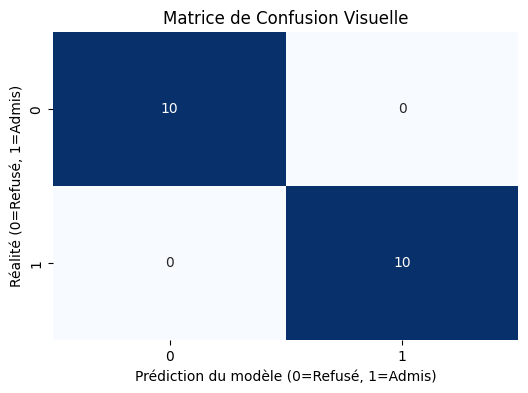

In [86]:
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Prédiction du modèle (0=Refusé, 1=Admis)')
plt.ylabel('Réalité (0=Refusé, 1=Admis)')
plt.title('Matrice de Confusion Visuelle')
plt.show()






*   Les 10 en haut à gauche (Vrais Négatifs) : Il y avait 10 étudiants qui devaient être refusés (0), et le modèle a correctement prédit "Refusé".

*   Les 10 en bas à droite (Vrais Positifs) : Il y avait 10 étudiants qui devaient être admis (1), et le modèle a correctement prédit "Admis".

*   Les 0 (La diagonale blanche) : Le modèle n'a fait aucune erreur. Il n'a ni refusé un bon étudiant, ni accepté un mauvais



